In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import os
import pandas as pd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from bci.signal.ssvep import SSVEPDetector,FlickerResult
from bci.ml.classifiers import ImageryClassifier, ActiveClassifier, MixedClassifier
from bci.ml.voting import PredictionAccumulator
from bci.signal.preprocessing import preprocess_global

File Paths

In [2]:
# ==========================================
# CHANGE THESE
# ==========================================

LOG_FILE = "../data/22-05/s2_log.csv"
EEG_FILE = "../data/22-05/s2_eeg.txt"

# ==========================================
# EEG SETTINGS
# ==========================================

SAMPLE_RATE = 125
EPOCH_SEC = 1
OVERLAP = (1 - 0.8)

EPOCH_SAMPLES = SAMPLE_RATE * EPOCH_SEC
STRIDE = int(OVERLAP * SAMPLE_RATE)

**Load OpenBCI TXT**

In [3]:
# ==========================================
# FIND HEADER
# ==========================================

with open(EEG_FILE, "r", encoding="utf-8") as f:
    lines = f.readlines()

header_idx = None

for i, line in enumerate(lines):
    if "Sample Index" in line:
        header_idx = i
        break

if header_idx is not None:
    print("Header found at line:", header_idx)
else:
    print("Header not found")

Header found at line: 4


**Read EEG Data**

In [4]:
eeg_df = pd.read_csv(
    EEG_FILE,
    skiprows=header_idx
)

# Clean column names
eeg_df.columns = [c.strip() for c in eeg_df.columns]

print("Shape:", eeg_df.shape)

eeg_df.head()

Shape: (64455, 33)


,Sample Index,EXG Channel 0,EXG Channel 1,EXG Channel 2,EXG Channel 3,EXG Channel 4,EXG Channel 5,EXG Channel 6,EXG Channel 7,EXG Channel 8,...,Digital Channel 2 (D13),Digital Channel 3 (D17),Not Used.1,Digital Channel 4 (D18),Analog Channel 0,Analog Channel 1,Analog Channel 2,Timestamp,Marker Channel,Timestamp (Formatted)
0,208.0,-19959.459598,5395.621705,-168.152174,-19678.855798,-6526.485864,-16541.453188,-8461.521084,-11304.730034,-8967.631634,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.779461e+09,0.0,2026-05-22 16:38:16.056
1,0.0,-9507.023931,2730.153826,-602.044237,-10183.231256,-3092.766177,-8598.403168,-4961.640234,-6235.577909,-4468.873676,...,126.0,40.0,15.5,48.0,0.0,0.0,0.0,1.779461e+09,0.0,2026-05-22 16:38:16.158
2,2.0,-19056.337363,5409.703304,-1201.450968,-20455.713028,-6216.243650,-17280.021880,-9970.375594,-12531.550232,-7485.979198,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.779461e+09,0.0,2026-05-22 16:38:16.164
3,4.0,-19084.880541,5414.106597,-1223.601547,-20437.272839,-6233.365087,-17271.841141,-9967.447515,-12529.113892,-7530.570928,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.779461e+09,0.0,2026-05-22 16:38:16.171
4,6.0,-19041.607564,5428.255251,-1209.899927,-20396.615016,-6206.006552,-17232.435016,-9950.594300,-12505.443395,-7489.175497,...,126.0,64.0,15.5,64.0,0.0,0.0,0.0,1.779461e+09,0.0,2026-05-22 16:38:16.180


Keep Only 16 EEG Channels

In [5]:
eeg_channels = [f"EXG Channel {i}" for i in range(16)]

eeg_data = eeg_df[eeg_channels].values

print("EEG Shape:", eeg_data.shape)

EEG Shape: (64455, 16)


Parse EEG Time

In [6]:
eeg_time = pd.to_datetime(
    eeg_df["Timestamp (Formatted)"]
)

eeg_time.head()
# type(eeg_time.iloc[0])

0   2026-05-22 16:38:16.056
1   2026-05-22 16:38:16.158
2   2026-05-22 16:38:16.164
3   2026-05-22 16:38:16.171
4   2026-05-22 16:38:16.180
Name: Timestamp (Formatted), dtype: datetime64[us]

Load Event CSV <br>
Convert Event Time to Datetime

In [7]:
log_df = pd.read_csv(LOG_FILE)

log_df.head()

,Time,Experiment,Phase,Event,Detail,Action
0,16:38:42.790,TrainML,MLTrain,LSL_Connected,BCIBackend,BCI_Stream_Open
1,16:38:42.790,TrainML,MLTrain,Experiment_Start,TrainML,NaN
2,16:38:42.790,TrainML,MLTrain,Phase_Start,MLTrain,NaN
3,16:38:42.845,TrainML,MLTrain,Hover_Enter,Button: StartTestBCI,Hovering
4,16:38:42.848,TrainML,MLTrain,Dwell_Start,Button: StartTestBCI,Dwell_Started


In [8]:
record_date = eeg_time.iloc[0].date()

log_df["DateTime"] = pd.to_datetime(
    str(record_date) + " " + log_df["Time"]
)

log_df.head()

,Time,Experiment,Phase,Event,Detail,Action,DateTime
0,16:38:42.790,TrainML,MLTrain,LSL_Connected,BCIBackend,BCI_Stream_Open,2026-05-22 16:38:42.790
1,16:38:42.790,TrainML,MLTrain,Experiment_Start,TrainML,NaN,2026-05-22 16:38:42.790
2,16:38:42.790,TrainML,MLTrain,Phase_Start,MLTrain,NaN,2026-05-22 16:38:42.790
3,16:38:42.845,TrainML,MLTrain,Hover_Enter,Button: StartTestBCI,Hovering,2026-05-22 16:38:42.845
4,16:38:42.848,TrainML,MLTrain,Dwell_Start,Button: StartTestBCI,Dwell_Started,2026-05-22 16:38:42.848


**Extract time Window**

In [9]:
def get_segment(start_time, end_time):
    mask = (eeg_time >= start_time) & \
           (eeg_time <= end_time)
    
    return eeg_data[mask.values]

**Sliding WIndow EPoch Fucn**

In [10]:
def create_epochs(segment, epoch_len, stride):
    epochs = []

    for start in range(0, len(segment) - epoch_len + 1, stride):
        epoch = segment[start:start + epoch_len]
        epochs.append(epoch)

    return np.array(epochs)

In [11]:
#preprocess
Notch_freq = 50.0
def preprocess_epoch(
    epoch: np.array,
    low: float = 3.0,
    high: float = 60.0
    ):
    epoch_filt = epoch.copy()
    nyq = SAMPLE_RATE/2.0
    if Notch_freq < nyq:
        b_notch, a_notch = signal.iirnotch(Notch_freq/nyq, 30.0)
        epoch_filt = signal.filtfilt(b_notch,a_notch,epoch_filt,axis=0)
    sos = signal.butter(4,[low, high],btype = "bandpass", fs = SAMPLE_RATE, output = "sos")
    epoch_filt = signal.sosfiltfilt(sos,epoch_filt,axis =0)
    return epoch_filt

In [12]:
from collections import defaultdict
def extract_intervals(df):
    intervals = defaultdict(list)
    open_events = {}

    for _, row in df.iterrows():

        action = str(row["Action"]).strip()
        time = row["DateTime"]

        parts = action.rsplit("_", 1)
        if len(parts) != 2:
            continue

        base, suffix = parts

        if suffix == "Start":
            open_events[base] = time

        elif suffix == "End":
            if base in open_events:
                intervals[base].append({
                    "start": open_events[base],
                    "end": time
                })
                del open_events[base]

    return intervals

In [13]:
def build_event_epochs(events_dict):
    event_epochs = {}

    for event_name, intervals in events_dict.items():

        # skip Trial_Sequence
        if event_name == "Trial_Sequence":
            continue

        all_epochs = []

        for interval in intervals:

            segment = get_segment(
                interval["start"],
                interval["end"]
            )

            if len(segment) < EPOCH_SAMPLES:
                continue

            epochs = create_epochs(
                segment,
                EPOCH_SAMPLES,
                STRIDE
            )

            all_epochs.append(epochs)

        if len(all_epochs) > 0:

            event_epochs[event_name] = np.concatenate(
                all_epochs,
                axis=0
            )

    return event_epochs

In [14]:
det = extract_intervals(df=log_df)

In [15]:
event_epoch = build_event_epochs(det)


In [16]:
# flicker = event_epoch["Flicker"]
# active_training_door2 = event_epoch["Active_Training_Door2"]
# training_imagery_door2 = event_epoch["Training_Imagery_Door2"]
# training_active_door1 = event_epoch["Training_Active_Door1"]
# training_imagery_door1 = event_epoch["Training_Imagery_Door1"]
# training_active_door1_flicker = event_epoch["Training_Active_Door1_Flicker"]
# training_imagery_door1_flicker = event_epoch["Training_Imagery_Door1_Flicker"]
# AP1 = event_epoch["Active_Predict_1"]
# AP2 = event_epoch["Active_Predict_2"]
# IP1 = event_epoch["Imagery_Predict_1"]
# IP2 = event_epoch["Imagery_Predict_2"]

# # filter
# flickerFilt = np.array([preprocess_epoch(epoch) for epoch in flicker])
# active_training_door2_filt = np.array([preprocess_epoch(epoch) for epoch in active_training_door2])
# training_imagery_door2_filt = np.array([preprocess_epoch(epoch) for epoch in training_imagery_door2])
# training_active_door1_filt = np.array([preprocess_epoch(epoch) for epoch in training_active_door1])
# training_imagery_door1_filt = np.array([preprocess_epoch(epoch) for epoch in training_imagery_door1])
# training_active_door1_flicker_filt = np.array([preprocess_epoch(epoch) for epoch in training_active_door1_flicker])
# training_imagery_door1_flicker_filt = np.array([preprocess_epoch(epoch) for epoch in training_imagery_door1_flicker])
# AP1_filt = np.array([preprocess_epoch(epoch) for epoch in AP1])
# AP2_filt = np.array([preprocess_epoch(epoch) for epoch in AP2])
# IP1_filt = np.array([preprocess_epoch(epoch) for epoch in IP1])
# IP2_filt = np.array([preprocess_epoch(epoch) for epoch in IP2])


In [17]:
for name, data in event_epoch.items():
    print(name, data.shape)

Flicker (6, 125, 16)
Training_Active_Door1_Flicker (160, 125, 16)
Training_Imagery_Door1_Flicker (160, 125, 16)
Training_Active_Door1 (160, 125, 16)
Training_Imagery_Door1 (144, 125, 16)
Active_Training_Door2 (160, 125, 16)
Training_Imagery_Door2 (160, 125, 16)
Active_Predict_1 (16, 125, 16)
Predict_Imagery_1 (16, 125, 16)
Active_Predict_2 (16, 125, 16)
Predict_Imagery_2 (16, 125, 16)
Active_Predict_3 (16, 125, 16)
Predict_Imagery_3 (16, 125, 16)
Active_Predict_4 (16, 125, 16)
Predict_Imagery_4 (16, 125, 16)
Active_Predict_5 (16, 125, 16)
Predict_Imagery_5 (16, 125, 16)


In [18]:
filtered = {
    name: np.array([preprocess_epoch(epoch, 3.0, 40.0) for epoch in data])
    for name, data in event_epoch.items()
}

# shorthand helper
E = filtered

for name, data in E.items():
    print(name, data.shape)

Flicker (6, 125, 16)
Training_Active_Door1_Flicker (160, 125, 16)
Training_Imagery_Door1_Flicker (160, 125, 16)
Training_Active_Door1 (160, 125, 16)
Training_Imagery_Door1 (144, 125, 16)
Active_Training_Door2 (160, 125, 16)
Training_Imagery_Door2 (160, 125, 16)
Active_Predict_1 (16, 125, 16)
Predict_Imagery_1 (16, 125, 16)
Active_Predict_2 (16, 125, 16)
Predict_Imagery_2 (16, 125, 16)
Active_Predict_3 (16, 125, 16)
Predict_Imagery_3 (16, 125, 16)
Active_Predict_4 (16, 125, 16)
Predict_Imagery_4 (16, 125, 16)
Active_Predict_5 (16, 125, 16)
Predict_Imagery_5 (16, 125, 16)


In [19]:
##confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

In [20]:
def build_dataset(*groups):
    X = np.concatenate([g[0] for g in groups])
    y = np.concatenate([np.full(len(g[0]), g[1])for g in groups])
    return X, y

def train_test_model(model,X,y,title="Model",test_size=0.2,random_state=42):
    # -----------------------------
    # Split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_size,random_state=random_state,stratify=y)

    X_train = np.transpose(X_train, (0, 2, 1))
    X_test  = np.transpose(X_test, (0, 2, 1))
    # -----------------------------
    # Train
    # -----------------------------
    model.train(
        data=list(X_train),
        labels=list(y_train)
    )

    # -----------------------------
    # Evaluate
    # -----------------------------
    rows = []

    for x, y_true in zip(X_test, y_test):

        pred, conf = model.predict(x)

        rows.append({
            "true": y_true,
            "pred": pred,
            "correct": int(pred == y_true),
            "confidence": conf
        })

    df = pd.DataFrame(rows)

    # -----------------------------
    # Metrics
    # -----------------------------
    accuracy = df["correct"].mean()

    print("\n==============================")
    print(title)
    print("==============================")

    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(classification_report(df["true"], df["pred"]))

    plot_confusion_matrix(
        df["true"],
        df["pred"],
        title=f"{title} Confusion Matrix"
    )

    return model, df

In [21]:
def run_ap(model, X, acc, name):
    results = []

    for epoch in X:
        pred, conf = model.predict(epoch.T)

        acc.append(pred, conf, imagery_str="NA", imagery_conf=0.0)

        stable = acc.get_stable_prediction(name)

        if stable is not None:
            results.append(stable)
            acc.clear()

    return results

def print_ap_results(name, results):
    for i, res in enumerate(results):
        print(
            f"[{name} {i+1}] "
            f"Pred: {res['prediction']} | "
            f"Conf: {res['confidence']:.3f} | "
            f"Agree: {res['agreement']:.3f} | "
            f"Model: {res['model_name']}"
        )

acc_active = PredictionAccumulator(10,0.7,0.6)
img_active = PredictionAccumulator(10,0.7,0.6)
mix_active = PredictionAccumulator(10,0.7,0.6)

Active Door 1 vs Door 2

Computing rank from data with rank=None
    Using tolerance 13 (2.2e-16 eps * 16 dim * 3.6e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.

Active Model
Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.78      0.76        32
           2       0.77      0.72      0.74        32

    accuracy                           0.75        64
   macro avg       0.75      0.75      0.75        64
weighted avg       0.75      0.75      0.75        64



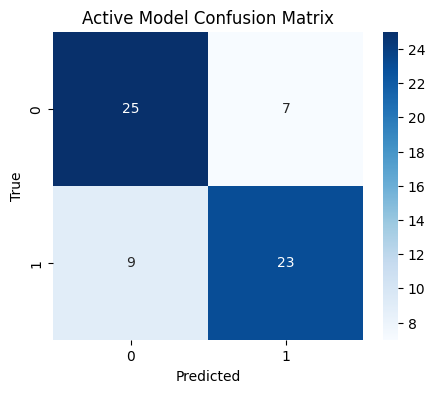

In [22]:
X_active, y_active = build_dataset(
    (E["Training_Active_Door1"], 1),
    (E["Active_Training_Door2"], 2)
)

active_model, active_df = train_test_model(
    ImageryClassifier(),
    X_active,
    y_active,
    test_size=0.2,
    title="Active Model"
)

Imagery d1 vs D2

Computing rank from data with rank=None


    Using tolerance 8.1 (2.2e-16 eps * 16 dim * 2.3e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.

Imagery Model
Accuracy: 0.7049180327868853

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.63      0.67       116
           2       0.70      0.77      0.73       128

    accuracy                           0.70       244
   macro avg       0.71      0.70      0.70       244
weighted avg       0.71      0.70      0.70       244



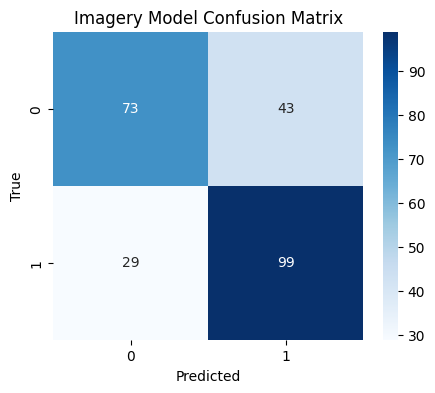

In [29]:
X_img, y_img = build_dataset((E["Training_Imagery_Door1"], 1),(E["Training_Imagery_Door2"], 2))

imagery_model, active_df = train_test_model(
    ImageryClassifier(),
    X_img,
    y_img,
    test_size=0.8,
    title="Imagery Model"
)

Computing rank from data with rank=None
    Using tolerance 11 (2.2e-16 eps * 16 dim * 3e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Estimating class=4 covariance using EMPIRICAL
Done.

Mix Model
Accuracy: 0.464

Classification Report:
              precision    recall  f1-score   support

           1       0.44      0.47      0.45       128
           2       0.39      0.55      0.46       128
           3       0.55      0.27      0.36       116
           4       0.55      0.55      0.55       128

    accuracy                           0.46       500
   macro avg       0.48      0.46      0.46       500
weighted avg       0.48      0.46      0.46       500



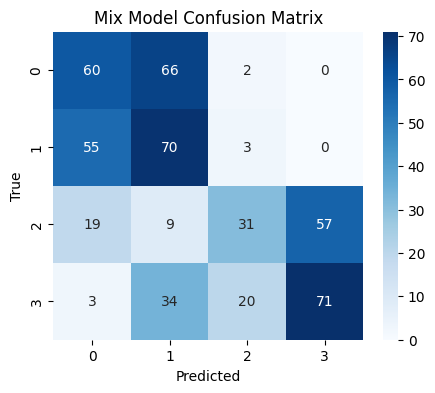

In [24]:
X_mix, y_mix = build_dataset(
    (E["Training_Active_Door1"], 1),
    (E["Active_Training_Door2"], 2),
    (E["Training_Imagery_Door1"], 3),
    (E["Training_Imagery_Door2"], 4)
)

mix_model, mix_df = train_test_model(
    ImageryClassifier(),
    X_mix,
    y_mix,
    test_size=0.8,
    title="Mix Model"
)

In [25]:
detector = SSVEPDetector(
    target_freq=15.0,   # example stimulus frequency
    detection_threshold= 0.6,
    fbcca_num_bands= 3,
    sfreq=125.0
)

results = []
# scores =[]
for epoch in E["Flicker"]:
    # epoch shape: (125, 16)
    epoch_input = epoch.T   # (16, 125)  ✔ required by detector
    result = detector.detect(epoch_input)
    results.append(result)

for i, r in enumerate(results):
    print(
        f"Epoch {i} | "
        f"Freq: {r.detected_frequency} | "
        f"Score: {r.confidence_score:.3f} | "
        f"SSVEP: {r.ssvep_present}"
    )

Epoch 0 | Freq: 15.0 | Score: 0.835 | SSVEP: True
Epoch 1 | Freq: 15.0 | Score: 0.564 | SSVEP: False
Epoch 2 | Freq: 15.0 | Score: 0.455 | SSVEP: False
Epoch 3 | Freq: 15.0 | Score: 0.689 | SSVEP: True
Epoch 4 | Freq: 15.0 | Score: 0.603 | SSVEP: True
Epoch 5 | Freq: 15.0 | Score: 0.699 | SSVEP: True


FLicker Door 1 vs Active door2

Computing rank from data with rank=None
    Using tolerance 13 (2.2e-16 eps * 16 dim * 3.7e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.

Flicker Vs Not Model
Accuracy: 0.890625

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.84      0.89        32
           1       0.86      0.94      0.90        32

    accuracy                           0.89        64
   macro avg       0.89      0.89      0.89        64
weighted avg       0.89      0.89      0.89        64



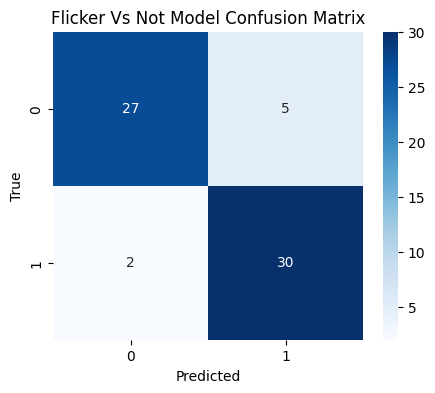

In [26]:
X_fn, y_fn = build_dataset(
    (E["Training_Active_Door1_Flicker"], 0),
    (E["Active_Training_Door2"], 1)
)

active_model, active_df = train_test_model(
    ImageryClassifier(),
    X_fn,
    y_fn,
    title="Flicker Vs Not Model"
)

In [27]:
AP1_active = run_ap(active_model, E["Active_Predict_1"], acc_active, "Active Test 1")
AP1_mix = run_ap(mix_model, E["Active_Predict_1"], mix_active, " mix Active Test 1")
acc_active.clear()
mix_active.clear()

AP2_active = run_ap(active_model, E["Active_Predict_2"], acc_active, "Active Test 2")
AP2_mix = run_ap(mix_model, E["Active_Predict_1"], mix_active, "mix Active Test 2")
acc_active.clear()
mix_active.clear()

AP3_active = run_ap(active_model, E["Active_Predict_3"], acc_active, "Active Test 3")
AP3_mix = run_ap(mix_model, E["Active_Predict_3"], mix_active, "Active Test 3")
acc_active.clear()

AP4_active = run_ap(active_model, E["Active_Predict_4"], acc_active, "Active Test 4")
acc_active.clear()

AP5_active = run_ap(active_model, E["Active_Predict_5"], acc_active, "Active Test 5")
acc_active.clear()

print_ap_results("AP1 Active", AP1_active)
print_ap_results("AP1 Mix", AP1_mix)
print("-------------------------------------------")
print_ap_results("AP2 Active", AP2_active)
print_ap_results("AP2 Mix", AP2_mix)
print("-------------------------------------------")
print_ap_results("AP3 Active", AP3_active)
print("-------------------------------------------")
print_ap_results("AP4 Active", AP4_active)
print("-------------------------------------------")
print_ap_results("AP5 Active", AP5_active)

[AP1 Active 1] Pred: 1 | Conf: 0.908 | Agree: 1.000 | Model: Active Test 1
-------------------------------------------
[AP2 Active 1] Pred: 1 | Conf: 0.838 | Agree: 0.900 | Model: Active Test 2
-------------------------------------------
[AP3 Active 1] Pred: 1 | Conf: 0.712 | Agree: 0.700 | Model: Active Test 3
-------------------------------------------
[AP4 Active 1] Pred: 1 | Conf: 0.941 | Agree: 1.000 | Model: Active Test 4
-------------------------------------------
[AP5 Active 1] Pred: 1 | Conf: 0.882 | Agree: 1.000 | Model: Active Test 5


In [28]:
IP1_active = run_ap(imagery_model, E["Predict_Imagery_1"], img_active, "Imagery Test 1")
IP1_mix = run_ap(mix_model, E["Predict_Imagery_1"], mix_active, " mix Imagery Test 1")
img_active.clear()
mix_active.clear()

IP2_active = run_ap(imagery_model, E["Predict_Imagery_2"], img_active, "Imagery Test 2")
IP2_mix = run_ap(mix_model, E["Predict_Imagery_2"], mix_active, "mix Imagery Test 2")
img_active.clear()
mix_active.clear()

IP3_active = run_ap(imagery_model, E["Predict_Imagery_3"], img_active, "Imagery Test 3")
IP3_mix = run_ap(mix_model, E["Predict_Imagery_3"], mix_active, " mix Imagery Test 3")
img_active.clear()
mix_active.clear()

IP4_active = run_ap(imagery_model, E["Predict_Imagery_4"], img_active, "Imagery Test 4")
IP4_mix = run_ap(mix_model, E["Predict_Imagery_4"], mix_active, "mix Imagery Test 4")
img_active.clear()
mix_active.clear()

IP5_active = run_ap(imagery_model, E["Predict_Imagery_5"], img_active, "Imagery Test 5")
IP5_mix = run_ap(mix_model, E["Predict_Imagery_5"], mix_active, "mix Imagery Test 5")
img_active.clear()
mix_active.clear()

print_ap_results("Test 2 Imagery Active", IP1_active)
print_ap_results("Test 2 Imagery Mix", IP1_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP2_active)
print_ap_results("Test 2 Imagery Mix", IP2_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP3_active)
print_ap_results("Test 2 Imagery Mix", IP3_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP4_active)
print_ap_results("Test 2 Imagery Mix", IP4_mix)
print("-------------------------------------------")
print_ap_results("Test 2 Imagery Active", IP5_active)
print_ap_results("Test 2 Imagery Mix", IP5_mix)

-------------------------------------------
[Test 2 Imagery Active 1] Pred: 1 | Conf: 0.694 | Agree: 0.900 | Model: Imagery Test 2
-------------------------------------------
[Test 2 Imagery Active 1] Pred: 2 | Conf: 0.814 | Agree: 0.700 | Model: Imagery Test 3
[Test 2 Imagery Mix 1] Pred: 4 | Conf: 0.635 | Agree: 0.700 | Model:  mix Imagery Test 3
-------------------------------------------
[Test 2 Imagery Active 1] Pred: 2 | Conf: 0.864 | Agree: 0.800 | Model: Imagery Test 4
[Test 2 Imagery Mix 1] Pred: 4 | Conf: 0.609 | Agree: 0.800 | Model: mix Imagery Test 4
-------------------------------------------
[Test 2 Imagery Active 1] Pred: 1 | Conf: 0.783 | Agree: 0.900 | Model: Imagery Test 5
[Test 2 Imagery Mix 1] Pred: 4 | Conf: 0.685 | Agree: 0.700 | Model: mix Imagery Test 5
